In [32]:
import os
import cv2
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision.io import read_image
import matplotlib.patches as patches
from pathlib import Path
from glob import glob
import shutil
import yaml
import zipfile
from ultralytics import YOLO
import re
from paddleocr import PaddleOCR
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from PIL import Image
import io

import warnings
warnings.filterwarnings("ignore")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [18]:
# from datasets import load_dataset

# ds = load_dataset("openfoodfacts/price-tag-detection")

In [20]:
splits = {'train': 'data/train-00000-of-00001.parquet', 'val': 'data/val-00000-of-00001.parquet'}
df_hf = pd.read_parquet("hf://datasets/openfoodfacts/price-tag-detection/" + splits["train"])

In [21]:
df_hf

,image_id,image,width,height,meta,objects
0,6485,{'bytes': b'RIFF\xe8\xd5\x00\x00WEBPVP8 \xdc\x...,768,1024,{'image_url': 'https://prices.openfoodfacts.or...,"{'bbox': [[0.25227088, 0.89401305, 0.3054115, ..."
1,12447,{'bytes': b'RIFF\x06$\x00\x00WEBPVP8 \xfa#\x00...,399,568,{'image_url': 'https://prices.openfoodfacts.or...,"{'bbox': [[0.10281617, 0.16644086, 0.91027963,..."
2,5744,{'bytes': b'RIFFB\xea\x01\x00WEBPVP8 6\xea\x01...,766,1024,{'image_url': 'https://prices.openfoodfacts.or...,"{'bbox': [[0.13917546, 0.7245445, 0.22600761, ..."
3,7067,{'bytes': b'RIFF\xc4\x8e\x01\x00WEBPVP8 \xb8\x...,768,1024,{'image_url': 'https://prices.openfoodfacts.or...,"{'bbox': [[0.2352132, 0.11187529, 0.29986244, ..."
4,2069,{'bytes': b'RIFFx\xe1\x01\x00WEBPVP8 l\xe1\x01...,1024,1024,{'image_url': 'https://prices.openfoodfacts.or...,"{'bbox': [[0.40776408, 0.08598665, 0.46294448,..."
...,...,...,...,...,...,...
1977,359,{'bytes': b'RIFF\\w\x00\x00WEBPVP8 Pw\x00\x00\...,333,923,{'image_url': 'https://prices.openfoodfacts.or...,"{'bbox': [[0.671837, 0.19940804, 0.9440208, 0...."
1978,8496,{'bytes': b'RIFF\x14p\x01\x00WEBPVP8 \x08p\x01...,768,1024,{'image_url': 'https://prices.openfoodfacts.or...,"{'bbox': [[0.6385105, 0.73893136, 0.6846857, 0..."
1979,8040,{'bytes': b'RIFF\xf8:\x01\x00WEBPVP8 \xec:\x01...,768,1024,{'image_url': 'https://prices.openfoodfacts.or...,"{'bbox': [[0.19299984, 0.49061853, 0.25553295,..."
1980,11777,{'bytes': b'RIFFF\xb8\x01\x00WEBPVP8 :\xb8\x01...,768,1024,{'image_url': 'https://prices.openfoodfacts.or...,"{'bbox': [[0.8445459, 0.25430092, 0.8755398, 0..."


In [29]:
#df_hf['image'].iloc[0]

In [24]:
df_hf['objects'].iloc[0]

{'bbox': array([array([    0.25227,     0.89401,     0.30541,     0.96487], dtype=float32), array([    0.23508,     0.96904,      0.2804,           1], dtype=float32), array([    0.44139,     0.86484,     0.48984,     0.94194], dtype=float32), array([    0.65708,     0.88568,     0.69771,     0.96278], dtype=float32),
        array([    0.87872,     0.93364,     0.93135,           1], dtype=float32)], dtype=object),
 'category_id': array([0, 0, 0, 0, 0], dtype=int64),
 'category_name': array(['price-tag', 'price-tag', 'price-tag', 'price-tag', 'price-tag'], dtype=object)}

In [25]:
outdir = "all_frames/images_hf"
os.makedirs(outdir, exist_ok=True)

for idx, item in enumerate(df_hf["image"]):
    img = Image.open(io.BytesIO(item["bytes"])).convert("RGB")
    img.save(f"{outdir}/{idx}.jpg")

In [27]:
rows = []

for idx, row in df_hf.iterrows():
    boxes = row['objects']['bbox']

    for box in boxes:
        ymin, xmin, ymax, xmax = box

        rows.append({
            'image_id': idx,
            'image': row['image'],
            'xmin': xmin,
            'ymin': ymin,
            'xmax': xmax,
            'ymax': ymax
        })

df_boxes = pd.DataFrame(rows)
df_boxes.head()

,image_id,image,xmin,ymin,xmax,ymax
0,0,{'bytes': b'RIFF\xe8\xd5\x00\x00WEBPVP8 \xdc\x...,0.894013,0.252271,0.964867,0.305411
1,0,{'bytes': b'RIFF\xe8\xd5\x00\x00WEBPVP8 \xdc\x...,0.969035,0.235078,1.000000,0.280404
2,0,{'bytes': b'RIFF\xe8\xd5\x00\x00WEBPVP8 \xdc\x...,0.864838,0.441389,0.941944,0.489841
3,0,{'bytes': b'RIFF\xe8\xd5\x00\x00WEBPVP8 \xdc\x...,0.885677,0.657077,0.962783,0.697714
4,0,{'bytes': b'RIFF\xe8\xd5\x00\x00WEBPVP8 \xdc\x...,0.933638,0.878719,1.000000,0.931350


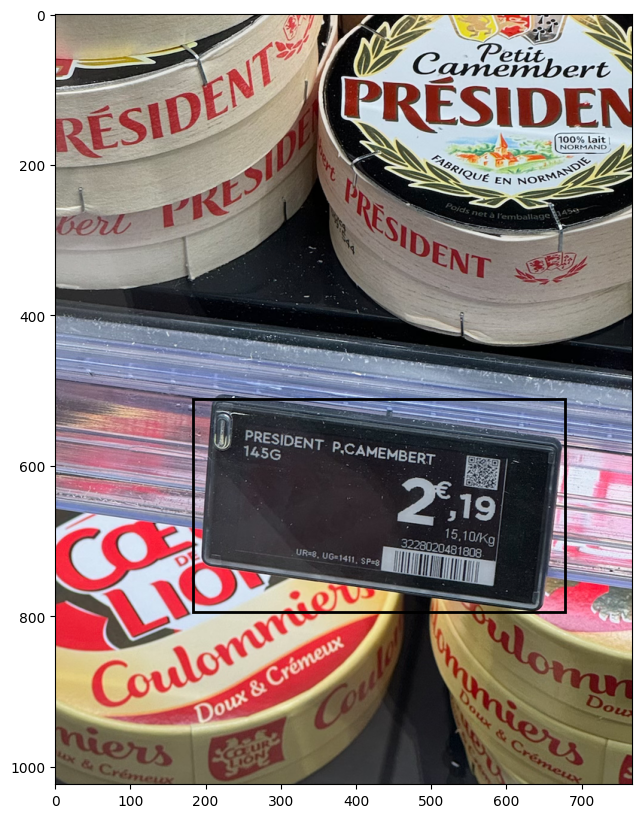

In [17]:
row = df_hf.iloc[5]
img = Image.open(io.BytesIO(row["image"]["bytes"])).convert("RGB")

fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(img)

w, h = img.size

for box in row["objects"]["bbox"]:
    ymin, xmin, ymax, xmax = box

    rect = patches.Rectangle(
        (xmin * w, ymin * h),
        (xmax - xmin) * w,
        (ymax - ymin) * h,
        linewidth=2,
        fill=False
    )
    ax.add_patch(rect)

plt.show()

In [30]:
from roboflow import Roboflow
rf = Roboflow(api_key="oYKnx2jEG7oKdHDKXDIn")
project = rf.workspace("hungduypham2004-gmail-com").project("price-tag-detection-cytf5")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Price-Tag-Detection-1 in yolov11:: 100%|███████| 5796/5796 [00:03<00:00, 1818.45it/s]


In [2]:
with zipfile.ZipFile("lenta_dataset.zip", "r") as zip_ref:
    zip_ref.extractall("lenta_dataset")

In [33]:
list_df = list(Path('lenta_dataset').rglob('*.csv'))
print(list_df[0])

lenta_dataset\sample.csv


In [34]:
list_df.remove(list_df[0])

In [35]:
len(list_df)

5

In [36]:
df1 = pd.read_csv(list_df[0])
df2 = pd.read_csv(list_df[1])
df3 = pd.read_csv(list_df[2])
df4 = pd.read_csv(list_df[3])
df5 = pd.read_csv(list_df[4])

In [6]:
for c1, c2, c3, c4, c5 in zip(df1.columns, df2.columns, df3.columns, df4.columns, df5.columns):
    if c1 != c2 or c1!=c3 or c1!=c4 or c1!=c5 or c2!=c3 or c2!=c4 or c2!=c5 or c3!=c4 or c3!=c5 or c4!=c5:
        print("Не совпадает:")
        print("df1:", c1)
        print("df2:", c2)
        print("df3:", c3)
        print("df4:", c4)
        print("df5:", c5)

Не совпадает:
df1: wholesale_level_1_count
df2: wholesale_level_1_count
df3: wholesale_level_1_coun
df4: wholesale_level_1_coun
df5: wholesale_level_1_count


In [7]:
df3.rename(columns={'wholesale_level_1_coun':'wholesale_level_1_count'}, inplace=True)
df4.rename(columns={'wholesale_level_1_coun':'wholesale_level_1_count'}, inplace=True)

In [8]:
len(df1.columns) == len(df2.columns) == len(df3.columns) == len(df4.columns) == len(df5.columns)

True

In [9]:
type(df1["frame_timestamp"].iloc[0])

numpy.int64

In [10]:
df1['filename'].unique()[0]

'25_12-20/2.mp4'

In [11]:
def clean_video_name(x):
    x = str(x).strip()          
    x = x.split("/")[0]        
    if not x.endswith(".mp4"):
        x += ".mp4"
    return x

dfs = [df1, df2, df3]

for df in dfs:
    df["filename"] = df["filename"].apply(clean_video_name)

df1['filename'].unique()[0]

'25_12-20.mp4'

In [15]:
root_dir = Path("lenta_dataset")
out_dir = Path("all_frames")
out_dir.mkdir(exist_ok=True)

In [16]:
dfs = [df1, df2, df3, df4, df5]

for df in dfs:
    df = df.copy()
    df["frame_timestamp"] = df["frame_timestamp"].astype(float)

    video_name = Path(str(df["filename"].iloc[0])).stem
    video_path = root_dir / video_name / f"{video_name}.mp4"

    print("Обрабатываю:", video_name)

    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)

    times = sorted(df["frame_timestamp"].drop_duplicates())
    target_frames = {
        int(round(t * fps / 1000)): int(t)
        for t in times
    }

    print("Нужно кадров:", len(target_frames))

    save_dir = out_dir / video_name
    save_dir.mkdir(exist_ok=True)

    current_frame = 0
    saved = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        if current_frame in target_frames:
            t = target_frames[current_frame]

            filename = save_dir / f"{t}.jpg"
            cv2.imwrite(str(filename), frame)

            saved += 1

        current_frame += 1

    cap.release()

    print("Сохранено:", saved)

Обрабатываю: 25_12-20
Нужно кадров: 10
Сохранено: 10
Обрабатываю: 25_2-10
Нужно кадров: 9
Сохранено: 8
Обрабатываю: 26_12-20
Нужно кадров: 15
Сохранено: 15
Обрабатываю: 43_15
Нужно кадров: 2
Сохранено: 2
Обрабатываю: 49_5
Нужно кадров: 25
Сохранено: 25


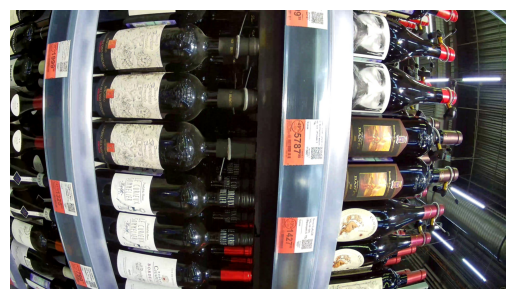

In [17]:
img = cv2.imread('all_frames/26_12-20/27156.jpg')
plt.axis('off')
plt.imshow(img[:, :, ::-1]);

In [18]:
df = pd.concat([df1, df2, df3, df4, df5], ignore_index = True)
df.head()

,filename,product_name,price_default,price_card,price_discount,barcode,discount_amount,id_sku,print_datetime,code,...,price1_qr,price2_qr,price3_qr,price4_qr,wholesale_level_1_count,wholesale_level_1_price,wholesale_level_2_count,wholesale_level_2_price,action_price_qr,action_code_qr
0,25_12-20.mp4,Напиток безалкогольный SANTO STEFANO Rosso (Ро...,"252,63","129,99",нет,4670025474665,-48%,270207736530,03.04.2026 3:08,нет,...,252.63,239.99,нет,129.99,нет,нет,нет,нет,нет,нет
1,25_12-20.mp4,Напиток безалкогольный SANTO STEFANO Bianco (Р...,"252,63","129,99",нет,4670025474658,-48%,270207736529,03.04.2026 3:08,нет,...,252.63,239.99,нет,129.99,нет,нет,нет,нет,нет,нет
2,25_12-20.mp4,Напиток безалкогольный ABRAU LIGHT Аромат. с/г...,"144,99","129,99",нет,4680140271438,-10%,270207716055,04.04.2026 1:09,нет,...,144.99,137.79,нет,129.99,нет,нет,нет,нет,нет,нет
3,25_12-20.mp4,Напиток безалкогольный ABRAU LIGHT Аромат. роз...,"144,99","129,99",нет,4680140271469,-10%,270207716056,04.04.2026 1:09,024 017_1_6_2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,25_12-20.mp4,Напиток безалкогольный ABRAU LIGHT Zero аромат...,"547,36","259,99",нет,4630027300508,-52%,270207659437,17.03.2026 13:27,нет,...,547.36,519.99,нет,259.99,нет,нет,нет,нет,нет,нет


In [19]:
cols = ['x_min', 'y_min', 'x_max', 'y_max']

df[cols] = df.apply(
    lambda row: pd.Series(
        [float(str(row[c]).replace(",", ".")) for c in cols],
        index=cols
    ),
    axis=1
)

In [20]:
df["img_path"] = df.apply(
    lambda row: str(
        out_dir /
        Path(row["filename"]).stem /
        f"{int(row['frame_timestamp'])}.jpg"
    ),
    axis=1
)
df.head()

,filename,product_name,price_default,price_card,price_discount,barcode,discount_amount,id_sku,print_datetime,code,...,price2_qr,price3_qr,price4_qr,wholesale_level_1_count,wholesale_level_1_price,wholesale_level_2_count,wholesale_level_2_price,action_price_qr,action_code_qr,img_path
0,25_12-20.mp4,Напиток безалкогольный SANTO STEFANO Rosso (Ро...,"252,63","129,99",нет,4670025474665,-48%,270207736530,03.04.2026 3:08,нет,...,239.99,нет,129.99,нет,нет,нет,нет,нет,нет,all_frames\25_12-20\0.jpg
1,25_12-20.mp4,Напиток безалкогольный SANTO STEFANO Bianco (Р...,"252,63","129,99",нет,4670025474658,-48%,270207736529,03.04.2026 3:08,нет,...,239.99,нет,129.99,нет,нет,нет,нет,нет,нет,all_frames\25_12-20\0.jpg
2,25_12-20.mp4,Напиток безалкогольный ABRAU LIGHT Аромат. с/г...,"144,99","129,99",нет,4680140271438,-10%,270207716055,04.04.2026 1:09,нет,...,137.79,нет,129.99,нет,нет,нет,нет,нет,нет,all_frames\25_12-20\0.jpg
3,25_12-20.mp4,Напиток безалкогольный ABRAU LIGHT Аромат. роз...,"144,99","129,99",нет,4680140271469,-10%,270207716056,04.04.2026 1:09,024 017_1_6_2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,all_frames\25_12-20\0.jpg
4,25_12-20.mp4,Напиток безалкогольный ABRAU LIGHT Zero аромат...,"547,36","259,99",нет,4630027300508,-52%,270207659437,17.03.2026 13:27,нет,...,519.99,нет,259.99,нет,нет,нет,нет,нет,нет,all_frames\25_12-20\5745.jpg


In [21]:
def visualize_from_df(df, img_path):
    sub = df[df["img_path"] == img_path]
    img = cv2.imread(img_path)
    img = img[:, :, ::-1]  

    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.imshow(img)

    for _, row in sub.iterrows():
        xmin = int(row["x_min"])
        ymin = int(row["y_min"])
        xmax = int(row["x_max"])
        ymax = int(row["y_max"])
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)
        ax.scatter(xmin, ymin, color='white', s=10)
        ax.scatter(xmax, ymax, color='white', s=10)
    ax.axis("off")
    plt.show()

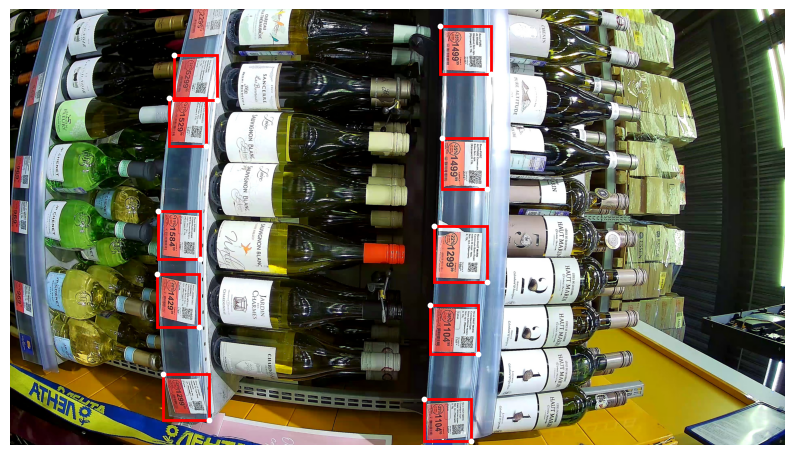

In [22]:
img_paths = df["img_path"].unique()

visualize_from_df(df, img_paths[10])

In [23]:
def pascal_voc_to_yolo_boxes(image, xmin, ymin, xmax, ymax):
    _, height, width = image.shape
    h = [ymax+ymin, ymax-ymin]
    w = [xmax+xmin, xmax-xmin]
    x_center = w[0]/2
    y_center = h[0]/2
    
    x_center_norm = x_center/width
    y_center_norm =  y_center/height
    width_norm = w[1]/width
    height_norm = h[1]/height
    yolo_bbox = [x_center_norm, y_center_norm, width_norm, height_norm]
    
    return yolo_bbox

In [24]:
def process_row(row):
    path = row['img_path']
    if not Path(path).exists():
        return None, None, None, None
    img = read_image(path)
    return pascal_voc_to_yolo_boxes(img, row.x_min, row.y_min, row.x_max, row.y_max)

results = df.apply(process_row, axis=1)
df[['x_c', 'y_c', 'w', 'h']] = pd.DataFrame(results.tolist(), index=df.index)

In [25]:
df[df['img_path'] == 'all_frames\\49_5\\400.jpg']

,filename,product_name,price_default,price_card,price_discount,barcode,discount_amount,id_sku,print_datetime,code,...,wholesale_level_1_price,wholesale_level_2_count,wholesale_level_2_price,action_price_qr,action_code_qr,img_path,x_c,y_c,w,h
227,49_5.mp4,Напиток кисломолочный MOLVEST Protein max высо...,231.57,159.99,нет,4 601751 028990,-30%,360102 864506,01.12.2025 18:21,нет,...,нет,нет,нет,нет,нет,all_frames\49_5\400.jpg,NaN,NaN,NaN,NaN


In [26]:
len(df)

274

In [27]:
df = df.dropna(subset=['x_c'])

In [28]:
len(df)

267

In [29]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False).head(3)

price3_qr         28.089888
print_datetime    27.340824
code               5.617978
dtype: float64

In [30]:
df[[col for col in df.columns if "qr" in col.lower()]]

,qr_code_barcode,price1_qr,price2_qr,price3_qr,price4_qr,action_price_qr,action_code_qr
0,4.670025e+12,252.63,239.99,нет,129.99,нет,нет
1,4.670025e+12,252.63,239.99,нет,129.99,нет,нет
2,4.680140e+12,144.99,137.79,нет,129.99,нет,нет
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.630027e+12,547.36,519.99,нет,259.99,нет,нет
...,...,...,...,...,...,...,...
269,4.607010e+12,152.69,144.99,нет,99.99,нет,нет
270,4.607053e+12,126.39,119.99,нет,92.99,нет,нет
271,4.640107e+12,157.89,149.99,нет,129.99,нет,нет
272,4.607010e+12,78.94,нет,нет,59.99,нет,нет


In [31]:
df['price3_qr'].fillna('нет', inplace=True)

In [32]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False).head(3)

print_datetime    27.340824
code               5.617978
id_sku             4.119850
dtype: float64

In [33]:
df['print_datetime'].fillna('нет', inplace=True)

In [34]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False).head()

code               5.617978
id_sku             4.119850
price2_qr          2.996255
price1_qr          1.872659
qr_code_barcode    1.872659
dtype: float64

In [35]:
df.dropna(inplace=True)

In [36]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False).head()

filename                   0.0
wholesale_level_2_count    0.0
price1_qr                  0.0
price2_qr                  0.0
price3_qr                  0.0
dtype: float64

In [37]:
len(df)

239

In [38]:
def enable_determinism():
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    torch.use_deterministic_algorithms(True)

def fix_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.mps.manual_seed(seed)


enable_determinism()
fix_seeds(24)

In [39]:
def visualize_yolo_bbox(image_np, bbox):
    fig, ax = plt.subplots(1)
    ax.imshow(image_np)

    h, w, _ = image_np.shape
    x_center, y_center, width, height = bbox

    x_center_pix = x_center * w
    y_center_pix = y_center * h
    width_pix = width * w
    height_pix = height * h

    xmin = int(x_center_pix - width_pix / 2)
    ymin = int(y_center_pix - height_pix / 2)
    xmax = int(x_center_pix + width_pix / 2)
    ymax = int(y_center_pix + height_pix / 2)

    rect = patches.Rectangle((xmin, ymin), width_pix, height_pix, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)

    ax.scatter(x_center_pix, y_center_pix, color='white', s=10, marker='o')
    plt.text(x_center_pix + 5, y_center_pix, f'({round(x_center,2)}, {round(y_center,2)})', fontsize=10, color='white', ha='right', va='bottom')

    plt.text(x_center_pix - 30, ymax + 15, f"Width: {width:.2f}", color='white', fontsize=10)
    plt.text(xmax + 15, y_center_pix, f"Height: {height:.2f}", color='white', fontsize=10)

    ax.set_xticks(np.linspace(0, w, num=9))  
    ax.set_yticks(np.linspace(0, h, num=10))  

    ax.set_xticklabels(np.linspace(0, 1, num=9), rotation=0)
    ax.set_yticklabels(np.round(np.linspace(0, 1, num=10), 2)) 
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    plt.axis("off")
    plt.show()

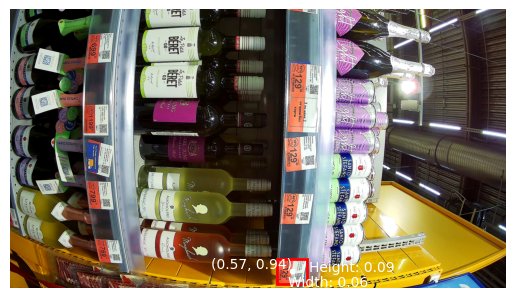

In [40]:
img = cv2.imread(df['img_path'].iloc[0])
bbox = df[['x_c', 'y_c', 'w', 'h']].iloc[0]
visualize_yolo_bbox(img[:, :, ::-1], bbox)

In [43]:
unique_images = df['img_path'].unique() 
np.random.shuffle(unique_images)
 
val_size = int(0.1 * len(unique_images))
val_images = set(unique_images[:val_size])
train_images = set(unique_images[val_size:])
 
df_train = df[df['img_path'].isin(train_images)]
df_val = df[df['img_path'].isin(val_images)]
 
print(f"Train images: {len(train_images)}")
print(f"Val images:   {len(val_images)}")

Train images: 49
Val images:   5


In [54]:
def create_dataset_template(path_to_create_dataset_template):
    new_dataset_path = Path(path_to_create_dataset_template)
    new_dataset_path.mkdir(exist_ok=True)
    
    path_to_train_images = Path(new_dataset_path, 'images', 'train')
    path_to_train_images.mkdir(exist_ok=True, parents=True,)
    
    path_to_train_labels = Path(new_dataset_path, 'labels', 'train')
    path_to_train_labels.mkdir(exist_ok=True, parents=True,)
    
    path_to_val_images = Path(new_dataset_path, 'images', 'val')
    path_to_val_images.mkdir(exist_ok=True, parents=True,)
    
    path_to_val_labels = Path(new_dataset_path, 'labels', 'val')
    path_to_val_labels.mkdir(exist_ok=True, parents=True,)
    
    absolute_path_to_dataset = new_dataset_path.resolve()
    absolute_path_to_train_images = path_to_train_images.resolve()
    absolute_path_to_train_labels = path_to_train_labels.resolve()
    absolute_path_to_val_images = path_to_val_images.resolve()
    absolute_path_to_val_labels = path_to_val_labels.resolve()
    
    return absolute_path_to_dataset, absolute_path_to_train_images, absolute_path_to_train_labels, absolute_path_to_val_images, absolute_path_to_val_labels

In [55]:
path_to_create_dataset_template = 'price_tag' 
path_to_dataset, path_to_train_images, path_to_train_labels, path_to_val_images, path_to_val_labels = create_dataset_template(path_to_create_dataset_template)

In [56]:
def prepare_dataset(df, path_to_save_images, path_to_save_labels):
    for index, row in df.iterrows():
        image_path = Path(row['img_path'])
        image_name = image_path.stem
        save_path_image = Path(path_to_save_images, image_path.name)
        if not save_path_image.exists():
            shutil.copy(image_path, save_path_image)
        yolo_boxes_str = f"0 {row['x_c']} {row['y_c']} {row['w']} {row['h']}\n"
        path_to_annotation = Path(path_to_save_labels, f'{image_name}.txt')
        with open(path_to_annotation, 'a') as f_out:
            f_out.write(yolo_boxes_str)


prepare_dataset(df_train, path_to_train_images, path_to_train_labels)
prepare_dataset(df_val, path_to_val_images, path_to_val_labels)

In [57]:
def generate_yaml_config(dataset_path, path_to_train, path_to_val):
    config = {
        'path': str(dataset_path),
        'train': str(path_to_train.relative_to(dataset_path)), 
        'val': str(path_to_val.relative_to(dataset_path)), 
        'names': {
            '0': 'price_tag'
            },
    
    }
    path_to_config = Path('config.yaml')
    with open('config.yaml', 'w') as file:
        yaml.dump(config, file)
    absolute_path_to_config = path_to_config.resolve()
    return absolute_path_to_config

generate_yaml_config(path_to_dataset, path_to_train_images, path_to_val_images)

WindowsPath('C:/Users/Маргарита/CV/lenta_hackaton/config.yaml')

In [64]:
model = YOLO('yolo11n.pt')

In [65]:
hparams = dict(
    degrees=5.0,
    translate=0.1,
    scale=0.3,        
    shear=2.0,
    perspective=0.0005,
    fliplr=0.5,
    flipud=0.0,
    hsv_h=0.015,
    hsv_s=0.4,        
    hsv_v=0.4,
    mosaic=1.0,
    mixup=0.05,       
    copy_paste=0.3,   
    erasing=0.2,      
)

In [66]:
train_results = model.train(
    data='config.yaml',
    epochs=100,          
    patience=50,          
    imgsz=1280,
    batch=8,
    rect=True,
    optimizer="AdamW",
    lr0=0.001,           
    warmup_epochs=5,      
    cos_lr=True,          
    freeze=10,            
    **hparams
)

New https://pypi.org/project/ultralytics/8.4.50 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.163  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=config.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.2, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train7, nbs=64, nms=False, opset=None, optimiz

train: Scanning C:\Users\Маргарита\CV\lenta_hackaton\price_tag\labels\train.cache... 47 images, 0 backgrounds, 0 corrup

train: C:\Users\\CV\lenta_hackaton\price_tag\images\train\0.jpg: 1 duplicate labels removed
train: C:\Users\\CV\lenta_hackaton\price_tag\images\train\40273.jpg: 1 duplicate labels removed
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
WARNING 'rect=True' is incompatible with DataLoader shuffle, setting shuffle=False


val: Fast image access  (ping: 0.10.0 ms, read: 972.0266.9 MB/s, size: 2302.4 KB)


val: Scanning C:\Users\Маргарита\CV\lenta_hackaton\price_tag\labels\val.cache... 5 images, 0 backgrounds, 0 corrupt: 10


...

     76/100      1.86G      1.154      1.202      1.183         33       1280: 100%|██████████| 6/6 [00:00<00:00,  7.99
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<0

                   all          5         20      0.174        0.3      0.176     0.0729
EarlyStopping: Training stopped early as no improvement observed in last 50 epochs. Best results observed at epoch 26, best model saved as best.pt.
To update EarlyStopping(patience=50) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



76 epochs completed in 0.032 hours.
Optimizer stripped from runs\detect\train7\weights\last.pt, 5.5MB
Optimizer stripped from runs\detect\train7\weights\best.pt, 5.5MB

Validating runs\detect\train7\weights\best.pt...
Ultralytics 8.3.163  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<0


                   all          5         20      0.833      0.499      0.532      0.228
Speed: 0.5ms preprocess, 3.8ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to runs\detect\train7
MLflow: results logged to runs\mlflow
MLflow: disable with 'yolo settings mlflow=False'


In [41]:
model_id = "IDEA-Research/grounding-dino-base"

processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)

In [82]:
image = Image.open(img_paths[10]).convert("RGB")
image = image.rotate(90, expand=True)

inputs = processor(
    images=image,
    text="price tag . label . shelf tag .",
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    threshold=0.25,
    target_sizes=[image.size[::-1]]
)

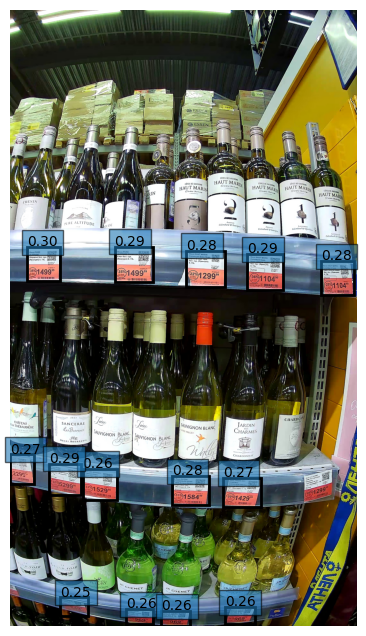

In [83]:
res = results[0]
img = np.array(image)

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img)

for box, score in zip(res["boxes"], res["scores"]):
    x1, y1, x2, y2 = box.cpu().numpy()

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=2
    )
    ax.add_patch(rect)

    ax.text(
        x1,
        y1 - 5,
        f"{score:.2f}",
        fontsize=10,
        bbox=dict(alpha=0.6)
    )

plt.axis("off")
plt.show()

In [ ]:
ocr = PaddleOCR(use_textline_orientation=True, lang='ru', text_det_limit_side_len=960)

In [45]:
img = cv2.imread('all_frames/25_12-20/0.jpg')
row = df1[df1['frame_timestamp'] == 0].iloc[0]
coords = row[['x_min', 'y_min', 'x_max', 'y_max']].astype(str)
coords = coords.str.replace(',', '.').astype(float)
x1, y1, x2, y2 = map(int, coords)
crop = img[y1:y2, x1:x2]
rotated = cv2.rotate(crop, cv2.ROTATE_90_COUNTERCLOCKWISE)

In [ ]:
results = ocr.predict(rotated)

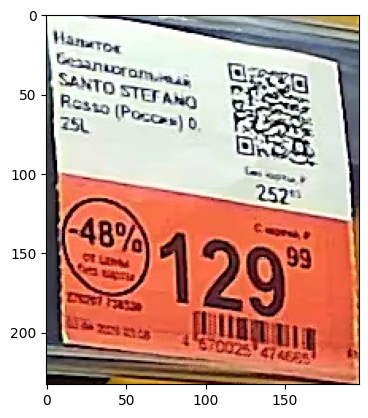

In [47]:
plt.imshow(rotated[:, :, ::-1])
plt.savefig('example.jpg')

In [50]:
!pip install pyzbar

   ---------------------------------------- 0.0/817.4 kB ? eta -:--:--
   ---------------------------------------- 817.4/817.4 kB 11.8 MB/s  0:00:00



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
img = cv2.imread('example.jpg')
h, w = img.shape[:2]

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray, (5, 5), 0)
#gray = cv2.CLAHE(gray)
gray = cv2.Canny(gray, 50, 150)
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT, (5, 5)
)
closed = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel, iterations = 2)
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [83]:
def order_points(pts):
    pts = np.array(pts, dtype = "float32")
    s = pts.sum(axis = 1)
    diff = np.diff(pts, axis = 1)
    ordered = np.zeros((4, 2), dtype = "float32")
    ordered[0] = pts[np.argmin(s)]
    ordered[2] = pts[np.argmax(s)]
    ordered[1] = pts[np.argmin(diff)]
    ordered[3] = pts[np.argmax(diff)]
    return ordered

screen_cnt = None
max_area = 0
for cnt in contours:
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
    if len(approx) == 4:
        area = cv2.contourArea(approx)
        if area > max_area:
            max_area = area
            screen_cnt = approx

pts = order_points(screen_cnt.reshape(4, 2))    

In [81]:
def four_point(image, pts):
    tl, tr, br, bl = pts
    widthA = np.linalg.norm(br - bl)
    widthB = np.linalg.norm(tr - tl)
    heightA = np.linalg.norm(tr - br)
    heightB = np.linalg.norm(tl - bl)
    maxWidth = int(max(widthA, widthB))
    maxHeight = int(max(heightA, heightB))

    dst = np.array(
        [
            [0, 0],
            [maxWidth-1, 0],
            [maxWidth-1, maxHeight-1],
            [0, maxHeight-1]
        ], dtype = 'float32'
    )
    M = cv2.getPerspectiveTransform(pts, dst)
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))
    return warped

warped = four_point(img, pts)

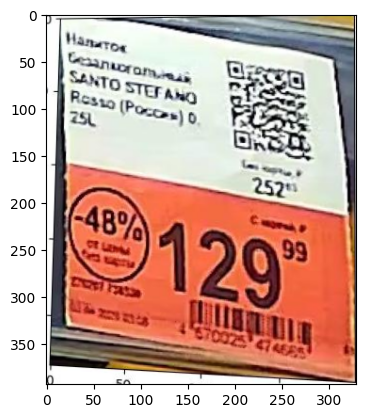

In [82]:
plt.imshow(warped[:, :, ::-1])

In [65]:
from pyzbar.pyzbar import decode
from PIL import Image

decoded = decode(Image.fromarray(gray))

for item in decoded:
    print(item.data.decode())

In [66]:
decoded

[]

In [92]:
row

filename                                                        25_12-20.mp4
product_name               Вино ФРОНТЕРА Шардоне сорт. орд. бел. п/ сух. ...
price_default                                                         631,57
price_card                                                            449,99
price_discount                                                           нет
barcode                                                        4973480846450
discount_amount                                                         -28%
id_sku                                                          270123794224
print_datetime                                                           NaN
code                                                               01_025019
additional_info                                                          нет
color                                                                    red
special_symbols                                                            К

In [93]:
#print(results[0]['rec_texts'])